In [0]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 18.7 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error

In [0]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url)

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

print(df.head())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


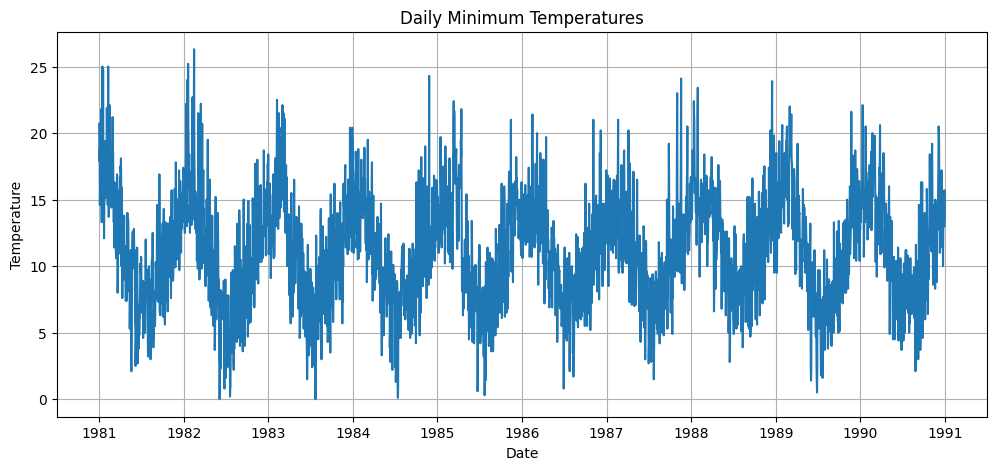

In [0]:
plt.figure(figsize=(12,5))

plt.plot(df["Temp"])

plt.title("Daily Minimum Temperatures")

plt.xlabel("Date")

plt.ylabel("Temperature")

plt.grid(True)

plt.show()

In [0]:
result = adfuller(df["Temp"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic : -4.444804924611703
p-value       : 0.00024708263003609586
Series is Stationary


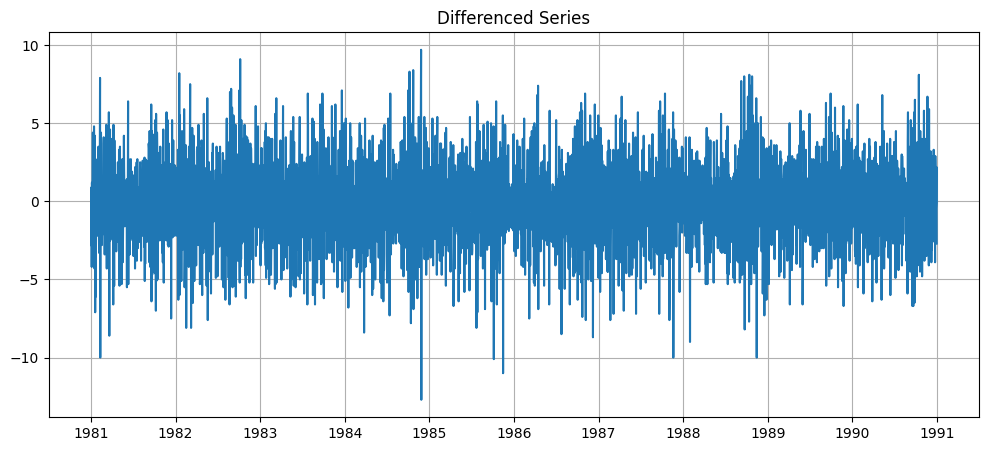

In [0]:
df["Temp_Diff"] = df["Temp"].diff()

plt.figure(figsize=(12,5))

plt.plot(df["Temp_Diff"])

plt.title("Differenced Series")

plt.grid(True)

plt.show()

In [0]:
result = adfuller(df["Temp_Diff"].dropna())

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

ADF Statistic : -18.028224167991986
p-value       : 2.681561822675178e-30


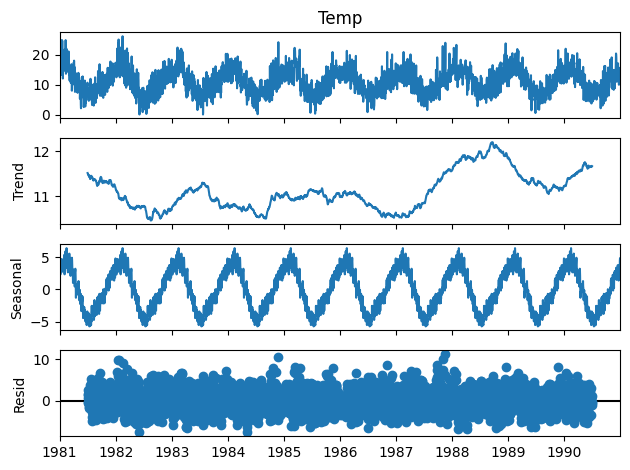

In [0]:
decomposition = seasonal_decompose(
    df["Temp"],
    model="additive",
    period=365
)

decomposition.plot()

plt.show()

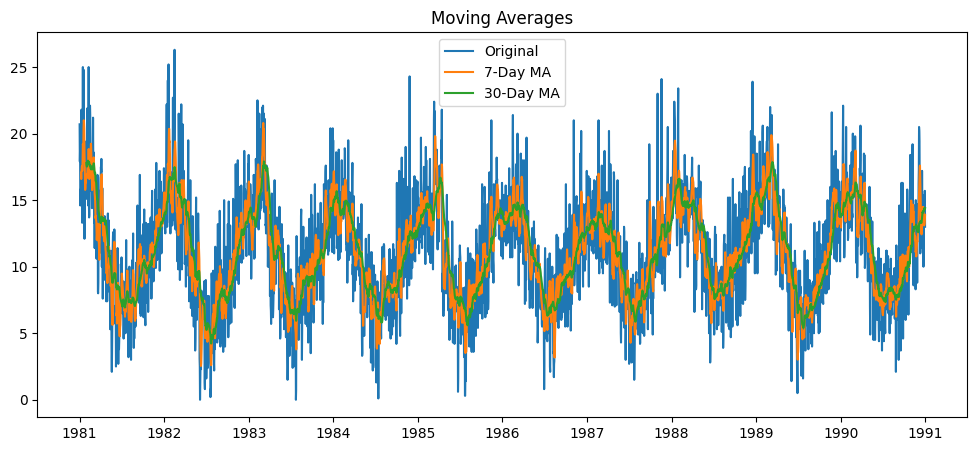

In [0]:
df["MA7"] = df["Temp"].rolling(window=7).mean()

df["MA30"] = df["Temp"].rolling(window=30).mean()

plt.figure(figsize=(12,5))

plt.plot(df["Temp"], label="Original")

plt.plot(df["MA7"], label="7-Day MA")

plt.plot(df["MA30"], label="30-Day MA")

plt.legend()

plt.title("Moving Averages")

plt.show()

In [0]:
last_ma = df["MA7"].iloc[-1]

ma_forecast = [last_ma] * 7

print("7-Day Moving Average Forecast")

print(ma_forecast)

7-Day Moving Average Forecast
[np.float64(13.900000000000002), np.float64(13.900000000000002), np.float64(13.900000000000002), np.float64(13.900000000000002), np.float64(13.900000000000002), np.float64(13.900000000000002), np.float64(13.900000000000002)]


In [0]:
last_value = df["Temp"].iloc[-1]

naive_forecast = [last_value] * 7

print("7-Day Naive Forecast")

print(naive_forecast)

7-Day Naive Forecast
[np.float64(13.0), np.float64(13.0), np.float64(13.0), np.float64(13.0), np.float64(13.0), np.float64(13.0), np.float64(13.0)]


In [0]:
train = df.iloc[:-7]

test = df.iloc[-7:]

In [0]:
forecast = [train["Temp"].rolling(7).mean().iloc[-1]] * 7

mae = mean_absolute_error(
    test["Temp"],
    forecast
)

print("MAE =", mae)

MAE = 0.7469387755102039


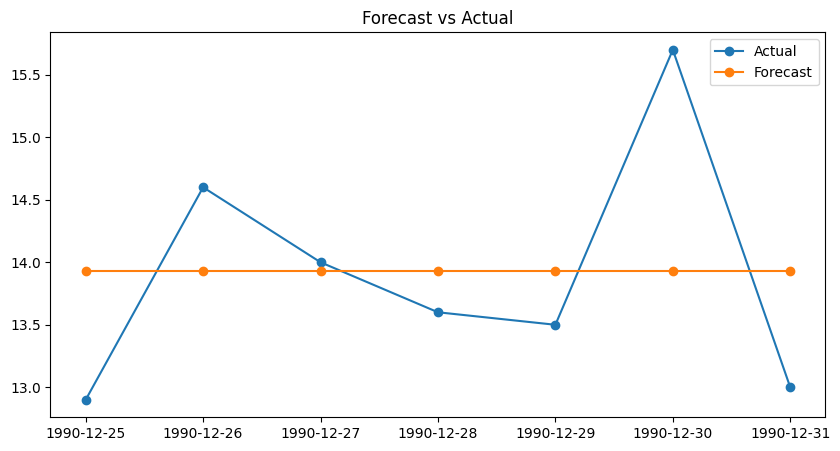

In [0]:
plt.figure(figsize=(10,5))

plt.plot(test.index, test["Temp"], marker="o", label="Actual")

plt.plot(test.index, forecast, marker="o", label="Forecast")

plt.legend()

plt.title("Forecast vs Actual")

plt.show()